In [ ]:
# Install spacy/transformers

!pip install --upgrade pip
!pip install -U spacy spacy-curated-transformers
!python -m spacy download en_core_web_trf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
INFO: pip is looking at multiple versions of spacy-curated-transformers to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 35.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [spacy-curated-transformers]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 24.3 MB/s  0:00:16
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Use GPU

import torch
import spacy

if spacy.prefer_gpu():
    print("Using GPU")
else:
    print("Using CPU")

nlp = spacy.load("en_core_web_trf")

Using GPU


In [ ]:
import pandas as pd
import numpy as np
# Import Hawkins 2020 Dataset (with chit-chat)
filteredURL = "https://github.com/hawkrobe/tangrams/blob/master/data/tangrams_sequential/message/sequential_message_filtered.csv"
df_filtered = pd.read_csv(filteredURL + "?raw=True")
df_filtered = df_filtered.drop(df_filtered[df_filtered['contents'].isna()].index)


# Import Hawkins 2020 Dataset (removed chit-chat)
finalURL = "https://github.com/hawkrobe/tangrams/blob/master/data/tangramsSequential.csv"
df_final = pd.read_csv(finalURL + "?raw=True")

In [ ]:
# Merge datasets in df_merged
df_merged = df_filtered.merge(df_final[["gameid", "trialNum", "role", "repetitionNum", "contents", "msgTime"]],
                               how='left', on=["gameid", "trialNum", "role", "repetitionNum", "msgTime"],
                               suffixes=["_original", "_final"])
# df_overall is df_merged with only relevant columns
df_overall = df_merged.drop(columns=["gameid","timeElapsed", "trialNum", "role", 'intendedName', "repetitionNum", 'msgTime'])
# Another checked to remove NA for original messages
df_edited = df_overall[~df_merged["contents_original"].isna()]
df_edited

,contents_original,contents_final
0,"hello, i am going to describe them as people a...",NaN
1,is that okay?,NaN
2,yes,NaN
3,this one kinda looks like they are looking a l...,this one kinda looks like they are looking a l...
4,wearing a dress maybe.,wearing a dress maybe.
...,...,...
9096,pack on back,pack on back
9097,"mourning, looking down","mourning, looking down"
9098,"kneeling,no limbs extended","kneeling,no limbs extended"
9099,"one foot on ground, other leg extended backward","one foot on ground, other leg extended backward"


In [ ]:
# Copy and pasted "additional_spellchecker" from Hawkins code
# https://github.com/hawkrobe/tangrams/blob/master/data/tangrams_sequential/message/additional_spell_correction.json
additional_spellchecker = {"this one iss" : "this one is", "hes" : "he is", "wit\\ his" : "with his", "whos" : "who is", "shes" : "she is", "dont" : "do not", "facing\\ eat" : "facing east", "man\\ who\\ as\\ and" : "man who has an", "i\\ calling" : "i keep calling", "doesn't't" : "doesn't", "a\\ diamond\\ on\\ to" : "a diamond on top", "sits\\ under\\ a\\ trip" : "sits under a tree", "doesnt" : "doesn't", "angles\\ wings" : "angel wings", "a\\ flag\\ on\\ it's\\ black" : "a flag on its back", "it's\\ chest" : "its chest", "king\\ of\\ lip" : "kind of lip", "r" : "right", "l" : "left", "this\\ on\\ looks\\ like": "this one looks like", "ice\\ skate" : "ice skater", "hands\\ up\\ in\\ ai" : "hands up in air", "stretch\\ ed\\ out" : "stretched out", "arms\\ to\\ he\\ right" : "arms to the right", "back\\ left\\ in\\ the\\ air" : "back leg in the air", "holding\\ a\\ table\\ or\\ something" : "holding a tablet or something", "right\\ food\\ in\\ the\\ air" : "right foot in the air", "angle\\ grad" : "angel grad", "slightly\\ o\\ right" : "slightly to right", "that got ate" : "that got eaten", "withthe" : "with the", "knees n hand" : "knees and hand", "withflag" : "with flag", "coffe" : "coffee", "impage" : "image", "square\\ at\\ the\\ tip" : "square at the top", "winged suse" : "winged dude", "diwn" : "down", "this one i": "this one is", "man\\ on\\ one\\ left" : "man on one leg", "holding\\ a\\ lunch\\ try" : "holding a lunch tray", "withknees" : "with knees", "reading\\ for\\ the\\ sky" : "reaching for the sky", "head\\ tipping\\ of" : "head tipping off", "w" : "with", "angle\\ with\\ arms\\ up" : "angel with arms up"}




In [ ]:
import re

better_spellcheck = {key.replace("\\ "," "): value for key, value in additional_spellchecker.items()}
better_spellcheck

# Fucntion that implents spellcheck
def replace_message(message):
  result = message
  for phrase in better_spellcheck.keys():
    if re.search(r'\b' + re.escape(phrase) + r'\b', result, re.IGNORECASE):
      result = re.sub(phrase, better_spellcheck[phrase], result)
  return result


In [ ]:
# Implements spellcheck for each original message

df_edited["contents_original"] = df_edited["contents_original"].apply(replace_message)
df_edited[0:10]

,contents_original,contents_final
0,"hello, i am going to describe them as people a...",NaN
1,is that okay?,NaN
2,yes,NaN
3,this one kinda looks like they are looking a l...,this one kinda looks like they are looking a l...
4,wearing a dress maybe.,wearing a dress maybe.
5,good this one is sitting down,this one is sitting down
6,with his knees up,with his knees up
7,this one looks like a ghost almost,this one looks like a ghost almost
8,with his arms raised up,with his arms raised up
9,this one looks like he is balancing on one leg...,this one looks like he is balancing on one leg...


In [ ]:
# B-I-O tagging for each message in contents_original

import string
len(df_edited)
collection_of_labels = []
chars_to_strip = string.whitespace + string.punctuation

b_count = 0
i_count = 0
o_count = 0

for idx, row in df_edited.iterrows(): # Goes through each row
  labels = []
  orig_lst = row["contents_original"].split()
  final = row["contents_final"]
  idx_word_final = 0

  # If all words are cut:
  if ((pd.isna(final)) or (final == "")):
    labels.extend(["O"] * len(orig_lst))
  else:
    final_lst = final.split()

    # Go through each word
    # Dynamic programming: word is the upcoming word in original message, final_lst[idx_word_final] is upcoming word in final message
    # If these do not match, add "O" and move onto next word
    # If these do match, add B or I (depending on preceding label), and add 1 to idx_word_final
    for word in orig_lst:
      if ((idx_word_final < len(final_lst)) and
          (
              (word == final_lst[idx_word_final]) or
              (word.lstrip(chars_to_strip) == final_lst[idx_word_final]) or
              (word.rstrip(chars_to_strip) == final_lst[idx_word_final]) or
              (word.strip(chars_to_strip) == final_lst[idx_word_final])
          )
      ):
        if ((len(labels) == 0) or (labels[-1] == "O")):
          b_count += 1
          labels.append("B-REL")
        elif labels[-1] == "B-REL" or labels[-1] == "I-REL":
          i_count += 1
          labels.append("I-REL")
        else:
          print("error")
          print("orig_list")
        idx_word_final += 1
      elif ((idx_word_final >= len(final_lst)) or (word != final_lst[idx_word_final])):
          o_count += 1
          labels.append("O")
  if len(labels) != len(orig_lst):
    print(idx)
    print("orig: ", orig_lst)
    print("final: ", final_lst)
    print("labels: ", labels)


  collection_of_labels.append(labels)
print(f"B Count: {b_count}, I Count: {i_count} O Count: {o_count}")

B Count: 7853, I Count: 37462 O Count: 578


In [ ]:
# Split messages/labels by punctuation

import string
punctuation_set = set(string.punctuation) - {"'", '"'}

new_lst = []
new_labels = []
for idx, sentence in df_edited["contents_original"].items():
  word_lst = sentence.split()
  old_idx = 0
  for idx2, word in enumerate(word_lst):
    if any(char in punctuation_set for char in word):
      new_idx = idx2
      new_lst.append(word_lst[old_idx:new_idx + 1])
      new_labels.append(collection_of_labels[idx][old_idx:new_idx + 1])
      old_idx = new_idx + 1
      last_punc = True
    else:
      last_punc = False
  if not last_punc:
      new_lst.append(word_lst[old_idx:])
      new_labels.append(collection_of_labels[idx][old_idx:])




In [ ]:
# Tag message parts as relevant or not by if they contain an B/I label

rows = []
for i in range(len(new_lst)):
  this_text = " ".join(new_lst[i])
  label = new_labels[i]
  if "B-REL" in label or "I-REL" in label:
    irrel = False
  else:
    irrel = True
  rows.append({"text": this_text,
             "message_irrelevant": irrel})
df_parts = pd.DataFrame(rows)


In [ ]:
# Remove blank

for idx, label in enumerate(new_labels):
  if not label:
    print(idx) # 6284
int(df_parts[df_parts["text"] == ""].index[0]) # 6284
df_parts_w_drop = df_parts.drop(int(df_parts[df_parts["text"] == ""].index[0])).reset_index(drop=True)

6284


In [ ]:
num_new_cols = 768

# Add symmantic definition in 768 vector space for each message to inputed dataframe

def addEmbeddings(df_in):
  lst_of_list_with_embeds = []

  # Go through each message
  texts = df_in["text"].tolist()  # list of all texts
  docs = list(nlp.pipe(texts, batch_size=16))
  for doc in docs:
      tensor = doc._.trf_data.last_hidden_layer_state
      dat = tensor.data
      means = np.mean(dat, axis=0)
      lst_of_list_with_embeds.append(means)
  embeddings_list_cpu = []

  # Convert to datafrane
  for embed_lst in lst_of_list_with_embeds:
      if hasattr(embed_lst, "detach"):
          embeddings_list_cpu.append(embed_lst.detach().cpu().numpy())
      elif hasattr(embed_lst, "get"):
          embeddings_list_cpu.append(embed_lst.get())
      else:
          embeddings_list_cpu.append(embed_lst)
  embeddings_array = np.vstack(embeddings_list_cpu).astype(np.float64)
  new_df = pd.DataFrame(embeddings_array,
                        columns=[f"dim space: {num}" for num in range(1, num_new_cols + 1)],
                        index=df_in.index)


  df_out = pd.concat([df_in, new_df], axis=1)
  df_out["message_irrelevant"] = df_out["message_irrelevant"].fillna(False).astype(bool)
  return df_out


df_hawk_parts_ed = addEmbeddings(df_parts_w_drop)


In [ ]:
# Save dataframe
df_hawk_parts_ed.to_csv("Hawkins_parts (3).csv")

In [ ]:
# If needed, load in dataframe
# import pandas as pd
# import numpy as np
# df_hawk_parts_ed = pd.read_csv("Hawkins_parts (3).csv")
#num_new_cols = 768

In [ ]:
# Fit models, cross validate (3 folds), and make predictions

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.metrics import classification_report

cols = [f"dim space: {i}" for i in range(1, num_new_cols + 1)]

X = df_hawk_parts_ed[cols]
y = df_hawk_parts_ed["message_irrelevant"]

RFC_model = RandomForestClassifier()

LR_model = LogisticRegression(max_iter=15000)

RFC_probas = cross_val_predict(RFC_model, X, y, cv=3, method='predict_proba')
RFC_pred = RFC_probas[:, 1]


LR_probas = cross_val_predict(LR_model, X, y, cv=3, method='predict_proba')
LR_pred = LR_probas[:, 1]


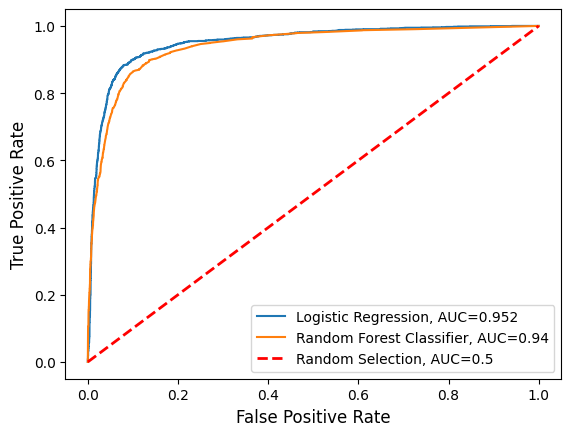

In [ ]:
# Build graphs and save results


from sklearn import metrics
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

LR_fpr, LR_tpr, LR_thresholds = metrics.roc_curve(y, LR_pred)
LR_auc = round(metrics.auc(LR_fpr, LR_tpr), 3)
plt.plot(LR_fpr, LR_tpr, label=f"Logistic Regression, AUC={LR_auc}")

RFC_fpr, RFC_tpr, RFC_thresholds = metrics.roc_curve(y, RFC_pred)
RFC_auc = round(metrics.auc(RFC_fpr, RFC_tpr), 3)
plt.plot(RFC_fpr, RFC_tpr, label=f"Random Forest Classifier, AUC={RFC_auc}")

plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Selection, AUC=0.5')



plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(fontsize=10)
plt.savefig("Hawkins_parts_CSV ROC Curve (5).png")
